# Milestone 3 Demo - Scenario Engine (Quantile ML Walk-Forward)

This notebook is a complete, model-specific evaluation for the Scenario Engine path based on `quantile_ml_walk_forward`.

It covers four required tasks end-to-end:
1. Identify and document the exact model and hyperparameters.
2. Train the model for each coin.
3. Compute evaluation metrics.
4. Produce clear evaluation charts.


## Model Scope and Code Mapping

The Scenario Engine model evaluated here is only:
- `quantile_ml_walk_forward` in `core/models/quantile_ml_walkforward_generator.py`

Underlying predictive model:
- Quantile regression with `GradientBoostingRegressor(loss="quantile")`
- Implemented in `core/models/probabilistic_quantile.py`
- One model is trained per quantile level.

What is intentionally excluded in this notebook:
- Monte Carlo scenario model
- Regime Similarity scenario model


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'core').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from core.models.probabilistic_quantile import (
    DEFAULT_FEATURES,
    add_next_day_target,
    prepare_model_frame,
    time_split,
    fit_quantile_models,
    predict_quantiles,
)
from core.pipelines.scenario_engine import ScenarioEngine, ScenarioConfig
from core.models.quantile_ml_walkforward_generator import WalkForwardMLConfig

print('Project root:', ROOT)


Project root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


## Configuration and Hyperparameters

The table below is the explicit configuration used for training and evaluation.


In [2]:
# Data and artifact paths
FEATURE_DIR = ROOT / 'data' / 'processed' / 'features'
MODELS_ROOT = ROOT / 'artifacts' / 'models'
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

# Quantile training hyperparameters
TRAIN_FRAC = 0.80
QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
RANDOM_STATE = 42
N_ESTIMATORS = 200
LEARNING_RATE = 0.05
MAX_DEPTH = 3

# Walk-forward scenario hyperparameters
HORIZON_DAYS = 14
N_SCENARIOS = 1500
N_BACKTEST_POINTS = 8
SEED = 42

ML_WALK_CFG = WalkForwardMLConfig(
    models_root=str(MODELS_ROOT),
    warmup_rows=80,
    sampling_strategy='stratified',
    seed=SEED,
)

hyperparams_df = pd.DataFrame([
    ('TRAIN_FRAC', TRAIN_FRAC),
    ('QUANTILES', QUANTILES),
    ('RANDOM_STATE', RANDOM_STATE),
    ('N_ESTIMATORS', N_ESTIMATORS),
    ('LEARNING_RATE', LEARNING_RATE),
    ('MAX_DEPTH', MAX_DEPTH),
    ('DEFAULT_FEATURES', DEFAULT_FEATURES),
    ('HORIZON_DAYS', HORIZON_DAYS),
    ('N_SCENARIOS', N_SCENARIOS),
    ('N_BACKTEST_POINTS', N_BACKTEST_POINTS),
    ('SEED', SEED),
    ('WARMUP_ROWS', ML_WALK_CFG.warmup_rows),
    ('SAMPLING_STRATEGY', ML_WALK_CFG.sampling_strategy),
    ('STRATIFIED_BINS', ML_WALK_CFG.stratified_bins),
], columns=['hyperparameter', 'value'])

display(hyperparams_df)


,hyperparameter,value
0,TRAIN_FRAC,0.8
1,QUANTILES,"[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, ..."
2,RANDOM_STATE,42
3,N_ESTIMATORS,200
4,LEARNING_RATE,0.05
5,MAX_DEPTH,3
6,DEFAULT_FEATURES,"[log_ret_1d, log_ret_5d, log_ret_10d, vol_7d, ..."
7,HORIZON_DAYS,14
8,N_SCENARIOS,1500
9,N_BACKTEST_POINTS,8


## Helper Functions

This section defines reusable helpers for:
- training and saving quantile bundles,
- one-step test evaluation,
- walk-forward backtest anchoring,
- scenario-path terminal statistics.


In [3]:
def pinball_loss(y_true: np.ndarray, y_pred: np.ndarray, q: float) -> float:
    err = y_true - y_pred
    return float(np.mean(np.maximum(q * err, (q - 1.0) * err)))


def load_features(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    df['close'] = pd.to_numeric(df['close'], errors='coerce')
    df = df.dropna(subset=['close']).reset_index(drop=True)
    return df


def fit_eval_save_one_coin(fp: Path):
    raw = load_features(fp)
    with_target = add_next_day_target(raw, ret_col='log_ret_1d')
    model_df, feats, target_col = prepare_model_frame(with_target, feature_cols=DEFAULT_FEATURES)

    train_df, test_df = time_split(model_df, train_frac=TRAIN_FRAC)

    bundle = fit_quantile_models(
        train_df=train_df,
        feature_cols=feats,
        target_col=target_col,
        quantiles=QUANTILES,
        random_state=RANDOM_STATE,
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        max_depth=MAX_DEPTH,
    )

    ticker = str(raw['ticker'].dropna().iloc[-1]) if 'ticker' in raw.columns and raw['ticker'].notna().any() else fp.stem.replace('_features', '')

    out_dir = MODELS_ROOT / ticker
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / 'quantile_model_bundle.joblib'

    joblib.dump({
        'ticker': ticker,
        'bundle': bundle,
        'feature_cols': feats,
        'target_col': target_col,
        'train_rows': len(train_df),
        'test_rows': len(test_df),
        'source_csv': str(fp),
        'hyperparameters': {
            'train_frac': TRAIN_FRAC,
            'quantiles': QUANTILES,
            'random_state': RANDOM_STATE,
            'n_estimators': N_ESTIMATORS,
            'learning_rate': LEARNING_RATE,
            'max_depth': MAX_DEPTH,
            'feature_cols': feats,
        },
    }, out_path)

    qpred = predict_quantiles(bundle, test_df)
    y_true = test_df[target_col].to_numpy(dtype=float)

    per_q = []
    for q in QUANTILES:
        col = f'q_{q:.2f}'
        per_q.append({
            'coin': ticker,
            'quantile': float(q),
            'pinball_loss': pinball_loss(y_true, qpred[col].to_numpy(dtype=float), q),
        })

    q50 = qpred['q_0.50'].to_numpy(dtype=float)
    mae = float(np.mean(np.abs(q50 - y_true)))
    rmse = float(np.sqrt(np.mean((q50 - y_true) ** 2)))
    direction_acc = float(np.mean(np.sign(q50) == np.sign(y_true)))

    coverage_90 = float(np.mean((y_true >= qpred['q_0.05'].to_numpy()) & (y_true <= qpred['q_0.95'].to_numpy())))

    metrics_row = {
        'coin': ticker,
        'n_train': int(len(train_df)),
        'n_test': int(len(test_df)),
        'mae_q50': mae,
        'rmse_q50': rmse,
        'direction_accuracy_q50': direction_acc,
        'coverage_90': coverage_90,
        'mean_pinball_loss': float(np.mean([r['pinball_loss'] for r in per_q])),
        'model_path': str(out_path),
    }

    train_curve_rows = []
    for q in QUANTILES:
        model = bundle.models[float(q)]
        scores = getattr(model, 'train_score_', None)
        if scores is None:
            continue
        for i, score in enumerate(scores, start=1):
            train_curve_rows.append({
                'coin': ticker,
                'quantile': float(q),
                'iter': int(i),
                'train_loss': float(score),
            })

    pred_frame = pd.DataFrame({
        'coin': ticker,
        'date': test_df['date'].to_numpy(),
        'y_true': y_true,
        'q_0.50': q50,
        'q_0.05': qpred['q_0.05'].to_numpy(dtype=float),
        'q_0.95': qpred['q_0.95'].to_numpy(dtype=float),
    })

    return metrics_row, per_q, train_curve_rows, pred_frame


def make_anchor_indices(n_rows: int, horizon_days: int, min_hist: int, n_points: int) -> list[int]:
    end_max = n_rows - horizon_days - 1
    if end_max <= min_hist:
        return []
    grid = np.linspace(min_hist, end_max, num=n_points, dtype=int)
    return sorted(list(set([int(x) for x in grid])))


def compute_terminal_stats(paths: np.ndarray) -> dict:
    start = paths[:, 0]
    end = paths[:, -1]
    ret = (end / start) - 1.0
    return {
        'pred_mean': float(np.mean(ret)),
        'pred_p05': float(np.percentile(ret, 5)),
        'pred_p50': float(np.percentile(ret, 50)),
        'pred_p95': float(np.percentile(ret, 95)),
    }


## Section A - Quantile Model Training and One-Step Evaluation

This section trains quantile models per coin and evaluates one-step-ahead prediction quality.

Metrics reported:
- `MAE` and `RMSE` for median prediction (`q_0.50`)
- Direction accuracy for median prediction
- Coverage for `[q_0.05, q_0.95]`
- Pinball loss per quantile


In [4]:
feature_files = sorted(FEATURE_DIR.glob('*_features.csv'))
print(f'Feature files found: {len(feature_files)}')

metric_rows = []
pinball_rows = []
train_curve_rows = []
pred_frames = []
errors = []

for fp in feature_files:
    try:
        m, p, t, pred = fit_eval_save_one_coin(fp)
        metric_rows.append(m)
        pinball_rows.extend(p)
        train_curve_rows.extend(t)
        pred_frames.append(pred)
    except Exception as e:
        errors.append({'file': str(fp), 'error': str(e)})

metrics_df = pd.DataFrame(metric_rows).sort_values('coin').reset_index(drop=True)
pinball_df = pd.DataFrame(pinball_rows).sort_values(['coin', 'quantile']).reset_index(drop=True)
train_curve_df = pd.DataFrame(train_curve_rows).sort_values(['coin', 'quantile', 'iter']).reset_index(drop=True)
preds_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()
errors_df = pd.DataFrame(errors)

print('Trained coins:', len(metrics_df))
print('Training errors:', len(errors_df))
if not errors_df.empty:
    display(errors_df)

display(metrics_df)


Feature files found: 10


C:\Users\sia\AppData\Local\Temp\ipykernel_31944\1123428141.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\sia\AppData\Local\Temp\ipykernel_31944\1123428141.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Trained coins: 10
Training errors: 0


,coin,n_train,n_test,mae_q50,rmse_q50,direction_accuracy_q50,coverage_90,mean_pinball_loss,model_path
0,ADA-USD,2707,677,0.032542,0.044566,0.454948,0.927622,0.007850,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
1,AVAX-USD,1870,468,0.032821,0.047556,0.653846,0.925214,0.008091,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
2,BNB-USD,3472,868,0.016575,0.026387,0.718894,0.925115,0.004187,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
3,BTC-USD,5057,1265,0.014431,0.022570,0.740711,0.917787,0.003594,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
4,DOGE-USD,2707,677,0.035234,0.048229,0.412112,0.905465,0.008323,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
5,ETH-USD,4176,1045,0.021407,0.034599,0.738756,0.901435,0.005500,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
6,FLOKI-USD,2344,587,0.033658,0.054176,0.652470,0.902896,0.008742,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
7,LINK-USD,2707,677,0.033716,0.045873,0.410635,0.935007,0.008085,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
8,SOL-USD,2569,643,0.022886,0.034841,0.765163,0.942457,0.005933,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...
9,XRP-USD,2429,608,0.031065,0.047460,0.472039,0.906250,0.007886,C:\Users\sia\Desktop\capstone\src\Agentic-Cryp...


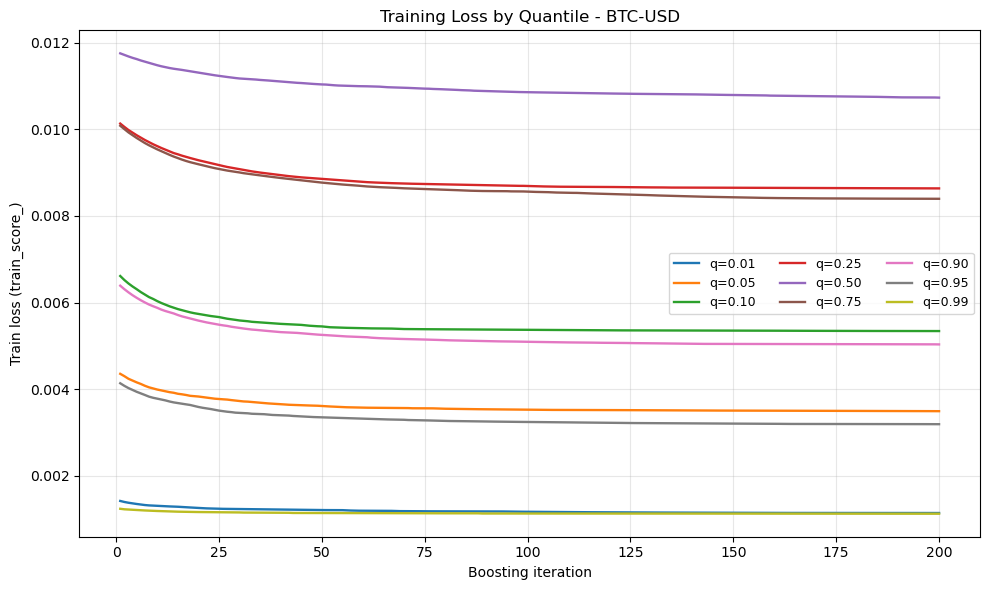

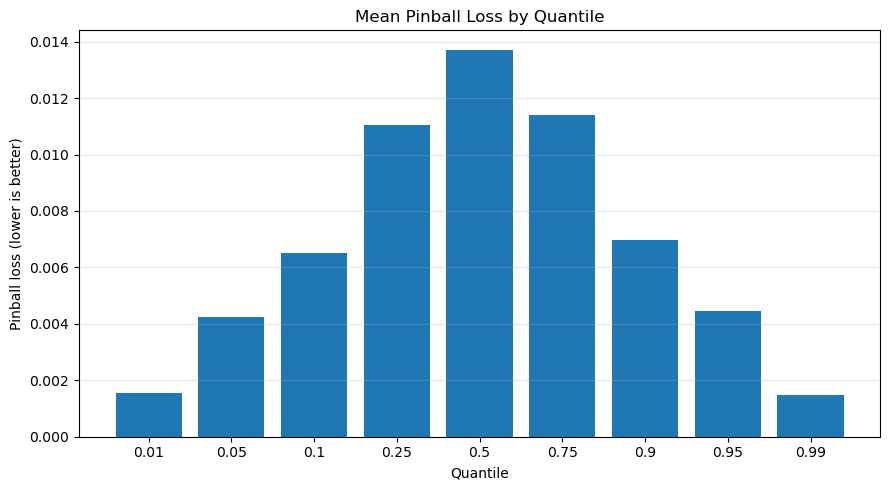

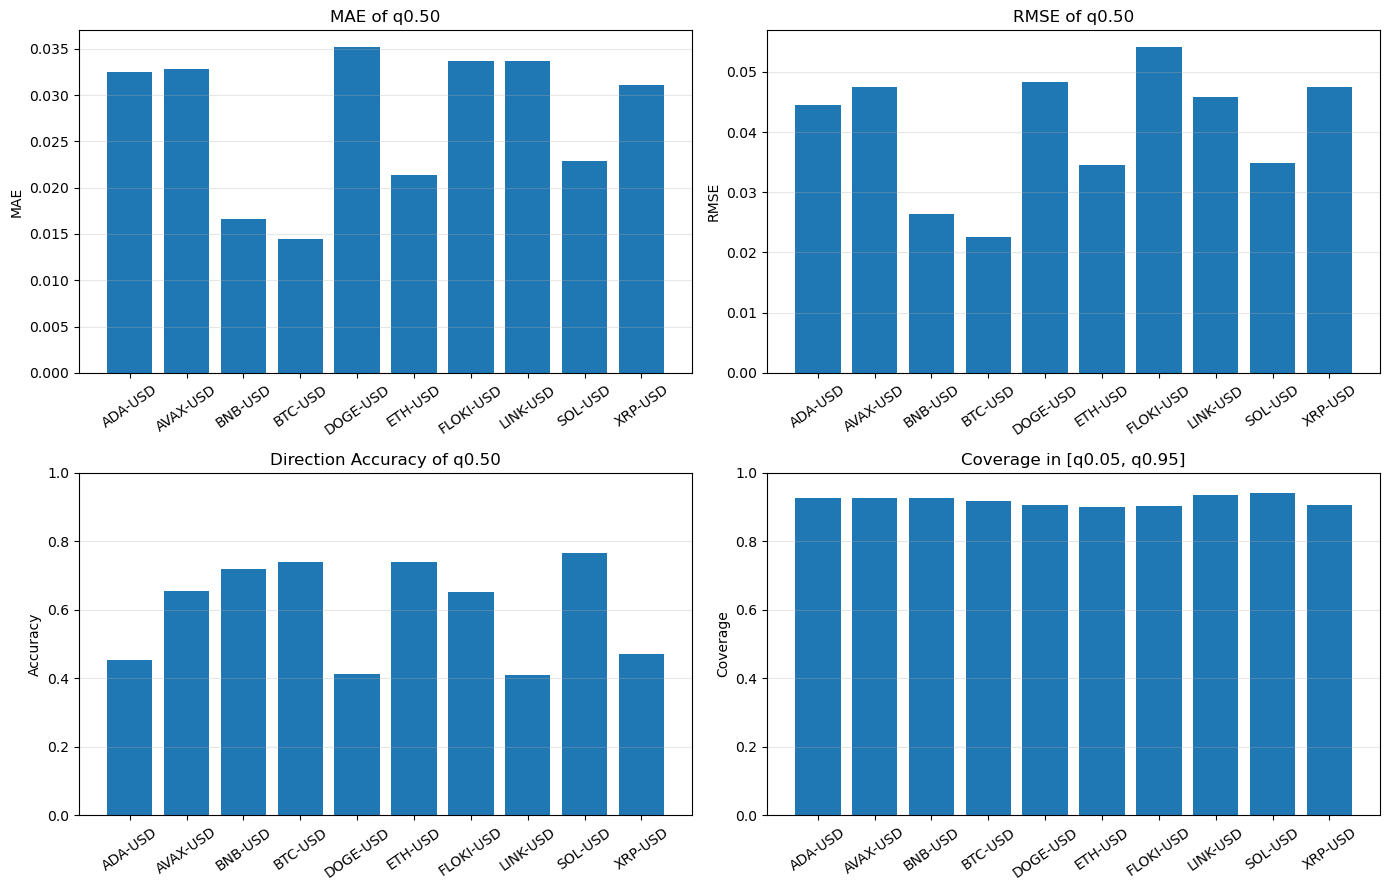

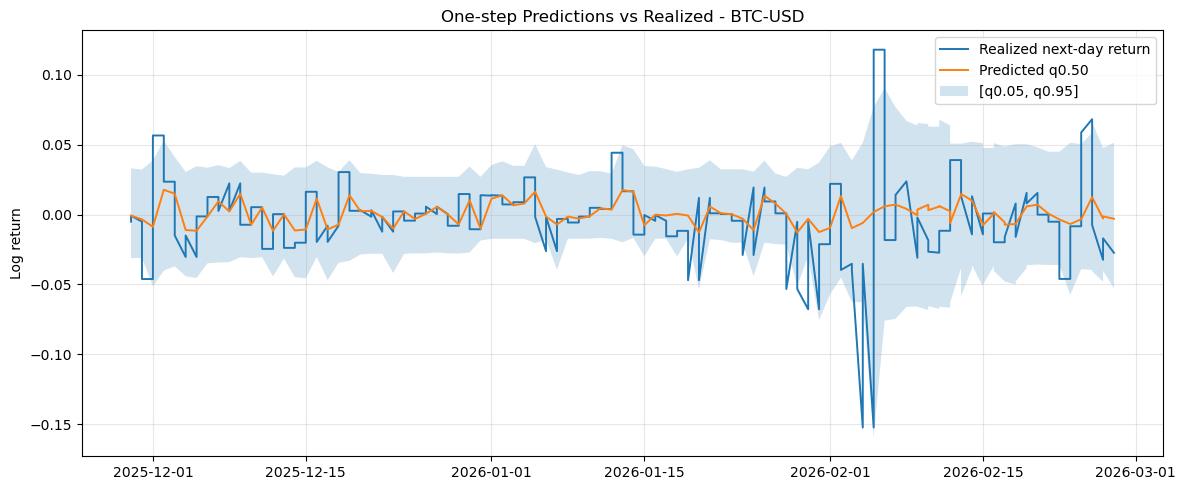

In [5]:
# Plot A1: Training loss curves by quantile for one sample coin
if train_curve_df.empty:
    raise RuntimeError('No training curves found.')

sample_coin = 'BTC-USD' if 'BTC-USD' in set(train_curve_df['coin']) else train_curve_df['coin'].iloc[0]
plot_df = train_curve_df[train_curve_df['coin'] == sample_coin]

fig, ax = plt.subplots(figsize=(10, 6))
for q in sorted(plot_df['quantile'].unique()):
    g = plot_df[plot_df['quantile'] == q]
    ax.plot(g['iter'], g['train_loss'], label=f'q={q:.2f}', linewidth=1.7)

ax.set_title(f'Training Loss by Quantile - {sample_coin}')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('Train loss (train_score_)')
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

# Plot A2: Mean pinball loss by quantile (across all coins)
pb_mean = pinball_df.groupby('quantile', as_index=False)['pinball_loss'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pb_mean['quantile'].astype(str), pb_mean['pinball_loss'])
ax.set_title('Mean Pinball Loss by Quantile')
ax.set_xlabel('Quantile')
ax.set_ylabel('Pinball loss (lower is better)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot A3: One-step test metrics per coin
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
mdf = metrics_df.sort_values('coin')

axes[0, 0].bar(mdf['coin'], mdf['mae_q50'])
axes[0, 0].set_title('MAE of q0.50')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].tick_params(axis='x', rotation=35)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(mdf['coin'], mdf['rmse_q50'])
axes[0, 1].set_title('RMSE of q0.50')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(mdf['coin'], mdf['direction_accuracy_q50'])
axes[1, 0].set_title('Direction Accuracy of q0.50')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(mdf['coin'], mdf['coverage_90'])
axes[1, 1].set_title('Coverage in [q0.05, q0.95]')
axes[1, 1].set_ylabel('Coverage')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot A4: Predicted vs realized series for one sample coin
sample_coin = 'BTC-USD' if 'BTC-USD' in set(preds_df['coin']) else preds_df['coin'].iloc[0]
g = preds_df[preds_df['coin'] == sample_coin].sort_values('date').tail(180)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(g['date'], g['y_true'], label='Realized next-day return', linewidth=1.4)
ax.plot(g['date'], g['q_0.50'], label='Predicted q0.50', linewidth=1.4)
ax.fill_between(g['date'], g['q_0.05'], g['q_0.95'], alpha=0.2, label='[q0.05, q0.95]')
ax.set_title(f'One-step Predictions vs Realized - {sample_coin}')
ax.set_ylabel('Log return')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Section B - Scenario Engine Walk-Forward Backtest

This section evaluates the actual `ScenarioEngine` run path with:
- `model_type='quantile_ml_walk_forward'`
- trained quantile bundles from Section A

Backtest logic:
- Build multiple anchor points per coin.
- Use historical data up to each anchor to generate scenario paths.
- Compare horizon predicted distribution statistics with realized horizon return.


In [6]:
wf_rows = []
wf_errors = []

for fp in feature_files:
    df = load_features(fp)
    coin = str(df['ticker'].dropna().iloc[-1]) if 'ticker' in df.columns and df['ticker'].notna().any() else fp.stem.replace('_features', '')

    anchors = make_anchor_indices(
        n_rows=len(df),
        horizon_days=HORIZON_DAYS,
        min_hist=ML_WALK_CFG.warmup_rows,
        n_points=N_BACKTEST_POINTS,
    )

    if not anchors:
        wf_errors.append({'coin': coin, 'anchor_idx': None, 'error': 'insufficient history'})
        continue

    for a_idx in anchors:
        hist = df.iloc[:a_idx + 1].copy()
        start_price = float(df.loc[a_idx, 'close'])
        future_price = float(df.loc[a_idx + HORIZON_DAYS, 'close'])
        realized_ret = (future_price / start_price) - 1.0

        try:
            engine = ScenarioEngine(features_df=hist)
            cfg = ScenarioConfig(
                asset=coin,
                horizon_days=HORIZON_DAYS,
                n_scenarios=N_SCENARIOS,
                seed=SEED,
                model_type='quantile_ml_walk_forward',
                ml_walk_cfg=ML_WALK_CFG,
            )
            out = engine.run(cfg)
            stats = compute_terminal_stats(out['paths'])

            pred_mean = stats['pred_mean']
            pred_p05 = stats['pred_p05']
            pred_p95 = stats['pred_p95']

            wf_rows.append({
                'coin': coin,
                'anchor_idx': int(a_idx),
                'anchor_date': pd.to_datetime(df.loc[a_idx, 'date']),
                'realized_ret': float(realized_ret),
                'pred_mean': float(pred_mean),
                'pred_p05': float(pred_p05),
                'pred_p95': float(pred_p95),
                'abs_error': float(abs(pred_mean - realized_ret)),
                'sq_error': float((pred_mean - realized_ret) ** 2),
                'direction_ok': int(np.sign(pred_mean) == np.sign(realized_ret)),
                'coverage_90': int((realized_ret >= pred_p05) and (realized_ret <= pred_p95)),
            })
        except Exception as e:
            wf_errors.append({'coin': coin, 'anchor_idx': int(a_idx), 'error': str(e)})

wf_df = pd.DataFrame(wf_rows)
wf_errors_df = pd.DataFrame(wf_errors)

print('Walk-forward rows:', len(wf_df))
print('Walk-forward errors:', len(wf_errors_df))
if not wf_errors_df.empty:
    display(wf_errors_df.head(20))

display(wf_df.head())


C:\Users\sia\AppData\Local\Temp\ipykernel_31944\1123428141.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\sia\AppData\Local\Temp\ipykernel_31944\1123428141.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Walk-forward rows: 79
Walk-forward errors: 1


,coin,anchor_idx,error
0,FLOKI-USD,485,Input X contains NaN.\nGradientBoostingRegress...


,coin,anchor_idx,anchor_date,realized_ret,pred_mean,pred_p05,pred_p95,abs_error,sq_error,direction_ok,coverage_90
0,ADA-USD,80,2018-02-27,-0.335314,0.004028,-0.283032,0.375069,0.339342,0.115153,0,0
1,ADA-USD,550,2019-06-12,0.003056,0.039889,-0.261310,0.432003,0.036833,0.001357,1,1
2,ADA-USD,1020,2020-09-24,0.161018,-0.000610,-0.289954,0.367838,0.161628,0.026123,0,1
3,ADA-USD,1490,2022-01-07,-0.072894,0.015649,-0.266694,0.375736,0.088543,0.007840,0,1
4,ADA-USD,1960,2023-04-22,-0.040474,0.044207,-0.237974,0.398558,0.084682,0.007171,0,1


Walk-forward overall summary


,n_runs,MAE,RMSE,direction_accuracy,coverage_90,mean_realized,mean_pred
0,79,0.140007,0.233382,0.367089,0.911392,0.011,0.049012


Walk-forward coin-level summary


,coin,n_runs,MAE,RMSE,direction_accuracy,coverage_90
0,ADA-USD,8,0.109983,0.144935,0.250000,0.875
1,AVAX-USD,8,0.197947,0.341565,0.625000,0.875
2,BNB-USD,8,0.046478,0.056260,0.500000,1.000
3,BTC-USD,8,0.104403,0.123368,0.375000,1.000
4,DOGE-USD,8,0.103721,0.149899,0.250000,0.875
5,ETH-USD,8,0.124768,0.143166,0.250000,1.000
6,FLOKI-USD,7,0.129301,0.146060,0.428571,1.000
7,LINK-USD,8,0.243783,0.367284,0.250000,0.750
8,SOL-USD,8,0.232903,0.411943,0.375000,0.875
9,XRP-USD,8,0.105447,0.124803,0.375000,0.875


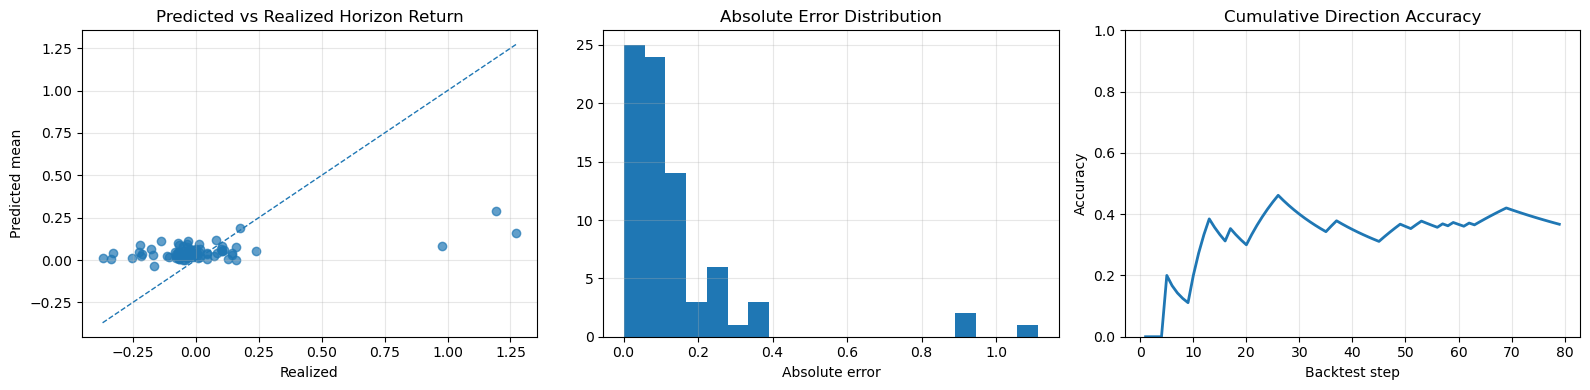

In [7]:
if wf_df.empty:
    raise RuntimeError('No walk-forward rows produced.')

wf_summary = pd.DataFrame([{
    'n_runs': len(wf_df),
    'MAE': float(wf_df['abs_error'].mean()),
    'RMSE': float(np.sqrt(wf_df['sq_error'].mean())),
    'direction_accuracy': float(wf_df['direction_ok'].mean()),
    'coverage_90': float(wf_df['coverage_90'].mean()),
    'mean_realized': float(wf_df['realized_ret'].mean()),
    'mean_pred': float(wf_df['pred_mean'].mean()),
}])

wf_coin_summary = (
    wf_df.groupby('coin', as_index=False)
    .agg(
        n_runs=('coin', 'size'),
        MAE=('abs_error', 'mean'),
        RMSE=('sq_error', lambda x: float(np.sqrt(np.mean(x)))),
        direction_accuracy=('direction_ok', 'mean'),
        coverage_90=('coverage_90', 'mean'),
    )
    .sort_values('coin')
    .reset_index(drop=True)
)

print('Walk-forward overall summary')
display(wf_summary)
print('Walk-forward coin-level summary')
display(wf_coin_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(wf_df['realized_ret'], wf_df['pred_mean'], alpha=0.7)
mn = min(float(wf_df['realized_ret'].min()), float(wf_df['pred_mean'].min()))
mx = max(float(wf_df['realized_ret'].max()), float(wf_df['pred_mean'].max()))
axes[0].plot([mn, mx], [mn, mx], linestyle='--', linewidth=1)
axes[0].set_title('Predicted vs Realized Horizon Return')
axes[0].set_xlabel('Realized')
axes[0].set_ylabel('Predicted mean')
axes[0].grid(alpha=0.3)

axes[1].hist(wf_df['abs_error'], bins=20)
axes[1].set_title('Absolute Error Distribution')
axes[1].set_xlabel('Absolute error')
axes[1].grid(alpha=0.3)

curve = wf_df.sort_values('anchor_date').reset_index(drop=True).copy()
curve['step'] = np.arange(1, len(curve) + 1)
curve['cum_acc'] = curve['direction_ok'].cumsum() / curve['step']
axes[2].plot(curve['step'], curve['cum_acc'], linewidth=2)
axes[2].set_title('Cumulative Direction Accuracy')
axes[2].set_xlabel('Backtest step')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Final Notes

- This notebook is fully focused on the quantile ML walk-forward pipeline.
- Quantile bundles saved here are directly compatible with `ScenarioEngine`.
- Re-run all cells with kernel `Python (mlhub)` to regenerate all metrics and plots.
